 # Setting up Spark environment

In [4]:
# Import Sparksession
from pyspark.sql import SparkSession

# Import col function used to reference DataFrame columns
from pyspark.sql.functions import col

# Import the 'when' function for conditional expression
from pyspark.sql.functions import when

# Import relevant libraries
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Create new spark session
spark = SparkSession.builder.appName('Network_Attack').master('yarn').getOrCreate()

In [6]:
# Print the current spark session
print(spark)

## Loading files

Publicly available dataset CICIDS2017 is composed of 8 different .csv files. These files have been previously saved into HDFS (Final_BDA directory) and are now loaded in Jupyter notebook

In [7]:
# Load and merge dataset and create DataFrame
file_paths = 'hdfs:///user/asell001/Final_BDA/*.csv'  # Pattern to match all CSV files in the directory
df = spark.read.option("header", "true").option("inferSchema", "true").csv(file_paths)

In [8]:
# Print the first rows to check the outcome
df.show(5)

+-----------------+--------------+------------------+-----------------------+---------------------------+----------------------------+----------------------+----------------------+-----------------------+----------------------+---------------------+----------------------+-----------------------+----------------------+------------+----------------+--------------+-------------+-------------+-------------+-------------+-------------+------------+------------+------------+-------------+-------------+------------+------------+------------+-------------+--------------+--------------+--------------+--------------------+------------------+----------------+--------------+------------------+------------------+-------------------+------------------+-----------------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+--------------+--------------------+---------------------+---------------------+--------------------+

# Exploratory Data Analysis

## Counting columns and rows in the DataFrame

In [9]:
# Count the number of rows in the DataFrame
num_rows = df.count()

# Count the number of columns in the DataFrame
num_columns = len(df.columns)

print(f"The DataFrame has {num_rows} rows and {num_columns} columns.")

The DataFrame has 2830743 rows and 79 columns.


## Display column names and data types

In [10]:
# Get the column names and data types
column_types = df.dtypes

# Iterate over the column_types list and print each item with a number
for i, (name, dtype) in enumerate(column_types, start=1):
    print(f"{i}. {name} | Data type: {dtype}")

1.  Destination Port | Data type: int
2.  Flow Duration | Data type: int
3.  Total Fwd Packets | Data type: int
4.  Total Backward Packets | Data type: int
5. Total Length of Fwd Packets | Data type: int
6.  Total Length of Bwd Packets | Data type: int
7.  Fwd Packet Length Max | Data type: int
8.  Fwd Packet Length Min | Data type: int
9.  Fwd Packet Length Mean | Data type: double
10.  Fwd Packet Length Std | Data type: double
11. Bwd Packet Length Max | Data type: int
12.  Bwd Packet Length Min | Data type: int
13.  Bwd Packet Length Mean | Data type: double
14.  Bwd Packet Length Std | Data type: double
15. Flow Bytes/s | Data type: double
16.  Flow Packets/s | Data type: double
17.  Flow IAT Mean | Data type: double
18.  Flow IAT Std | Data type: double
19.  Flow IAT Max | Data type: int
20.  Flow IAT Min | Data type: int
21. Fwd IAT Total | Data type: int
22.  Fwd IAT Mean | Data type: double
23.  Fwd IAT Std | Data type: double
24.  Fwd IAT Max | Data type: int
25.  Fwd IAT Min 

## Inconsistent whitespace issue
While analyzing the names of the columns we can see that there's a whitespace (' ') before the name of some of the variables. This inconsistency can cause problems in the future analysis as we have to refer to the exact column name in the code and not knowing whether there's a whitespace can be problematic. In the section below we will address this issue

In [11]:
# Check DataFrame schema
df.printSchema()

root
 |--  Destination Port: integer (nullable = true)
 |--  Flow Duration: integer (nullable = true)
 |--  Total Fwd Packets: integer (nullable = true)
 |--  Total Backward Packets: integer (nullable = true)
 |-- Total Length of Fwd Packets: integer (nullable = true)
 |--  Total Length of Bwd Packets: integer (nullable = true)
 |--  Fwd Packet Length Max: integer (nullable = true)
 |--  Fwd Packet Length Min: integer (nullable = true)
 |--  Fwd Packet Length Mean: double (nullable = true)
 |--  Fwd Packet Length Std: double (nullable = true)
 |-- Bwd Packet Length Max: integer (nullable = true)
 |--  Bwd Packet Length Min: integer (nullable = true)
 |--  Bwd Packet Length Mean: double (nullable = true)
 |--  Bwd Packet Length Std: double (nullable = true)
 |-- Flow Bytes/s: double (nullable = true)
 |--  Flow Packets/s: double (nullable = true)
 |--  Flow IAT Mean: double (nullable = true)
 |--  Flow IAT Std: double (nullable = true)
 |--  Flow IAT Max: integer (nullable = true)
 |-- 

In [12]:
# Get the current column names from the DataFrame
current_columns = df.columns

# Create a dictionary mapping current column names to trimmed column names
renamed_columns = {col_name: col_name.strip() for col_name in current_columns}

# Use selectExpr to select and rename columns in one go
df_clean = df.selectExpr(*(f"`{col}` as `{new_col}`" for col, new_col in renamed_columns.items()))

# Verify the new column names
df_clean.printSchema()


root
 |-- Destination Port: integer (nullable = true)
 |-- Flow Duration: integer (nullable = true)
 |-- Total Fwd Packets: integer (nullable = true)
 |-- Total Backward Packets: integer (nullable = true)
 |-- Total Length of Fwd Packets: integer (nullable = true)
 |-- Total Length of Bwd Packets: integer (nullable = true)
 |-- Fwd Packet Length Max: integer (nullable = true)
 |-- Fwd Packet Length Min: integer (nullable = true)
 |-- Fwd Packet Length Mean: double (nullable = true)
 |-- Fwd Packet Length Std: double (nullable = true)
 |-- Bwd Packet Length Max: integer (nullable = true)
 |-- Bwd Packet Length Min: integer (nullable = true)
 |-- Bwd Packet Length Mean: double (nullable = true)
 |-- Bwd Packet Length Std: double (nullable = true)
 |-- Flow Bytes/s: double (nullable = true)
 |-- Flow Packets/s: double (nullable = true)
 |-- Flow IAT Mean: double (nullable = true)
 |-- Flow IAT Std: double (nullable = true)
 |-- Flow IAT Max: integer (nullable = true)
 |-- Flow IAT Min: in

By printing 'df_clean' schema we can now see that there're no whitespaces before the columns names as compared to previous 'df' schema. This will make the analysis easier. 

## Selecting and counting different 'labels'
We will now proceed to analyze some of the main features of the newly created/cleaned DataFrame. We're interested in checking the type of network attacks gathered in the dataset for the purpose of this analysis

In [13]:
# Group the data by the 'Label' column and count the occurrences
label_counts = df_clean.groupBy(col("Label")).count()

# Sort the counts in descending order
label_counts = label_counts.orderBy(col("count").desc())

# Show the result
label_counts.show(truncate=False)

+--------------------------+-------+
|Label                     |count  |
+--------------------------+-------+
|BENIGN                    |2273097|
|DoS Hulk                  |231073 |
|PortScan                  |158930 |
|DDoS                      |128027 |
|DoS GoldenEye             |10293  |
|FTP-Patator               |7938   |
|SSH-Patator               |5897   |
|DoS slowloris             |5796   |
|DoS Slowhttptest          |5499   |
|Bot                       |1966   |
|Web Attack � Brute Force  |1507   |
|Web Attack � XSS          |652    |
|Infiltration              |36     |
|Web Attack � Sql Injection|21     |
|Heartbleed                |11     |
+--------------------------+-------+



## Visualizing the data
In the below chart we can see that most of the data in the merged dataset are labeled as 'BENIGN'. Moreover, the most common network attacks present in the dataset are 'PortScan' or some variation of 'DoS' attack.

In [14]:
# Convert the Spark DataFrame to a Pandas DataFrame
label_counts_pd = label_counts.toPandas()

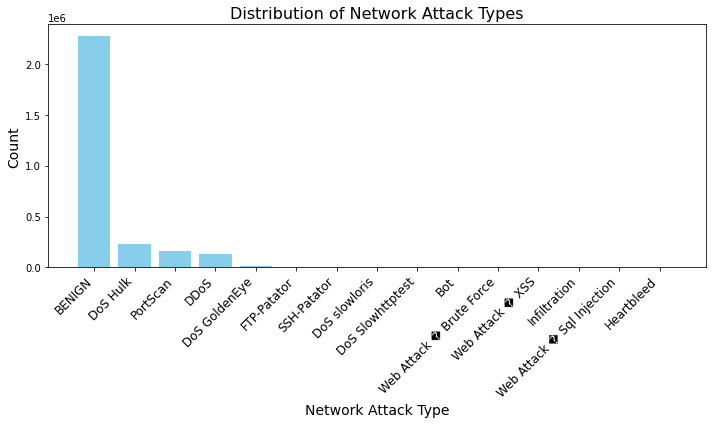

In [15]:
# Set the figure size and plot the bar graph
plt.figure(figsize=(10, 6))
plt.bar(label_counts_pd['Label'], label_counts_pd['count'], color='skyblue')
plt.xlabel('Network Attack Type', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.title('Distribution of Network Attack Types', fontsize=16)

# Show the plot
plt.tight_layout()
plt.show()

# Filtering the DataFrame
In order to create a more accurate prediction model, the project will be focussing only on two main types of network attacks: PortScan and DoS. Below the DataFrame will be filtered so to keep only the data points relevant for the study

In [16]:
# Filter the DataFrame to include only the specified labels
filtered_df = df_clean.filter(
    col("Label").isin("BENIGN", "PortScan", "DoS Hulk", "DDoS", "DoS GoldenEye", "DoS slowloris", "DoS Slowhttptest")
)

In [17]:
# Merge various types of DoS attacks into a single 'DoS' label
merged_df = filtered_df.withColumn(
    "Label", 
    when(col("Label").rlike("DoS|DDoS"), "DoS").otherwise(col("Label"))
)

In [18]:
# Let check out the results of the new DataFrame
# Group the data by the 'Label' column and count the occurrences
label_counts = merged_df.groupBy(col("Label")).count()

# Sort the counts in descending order
label_counts = label_counts.orderBy(col("count").desc())

# Show the result
label_counts.show(truncate=False)

+--------+-------+
|Label   |count  |
+--------+-------+
|BENIGN  |2273097|
|DoS     |380688 |
|PortScan|158930 |
+--------+-------+



In [19]:
# Define the list of column names 
columns_to_keep = [
    "Destination Port", "Flow Duration", "Total Fwd Packets", "Total Backward Packets",
    "Fwd Packet Length Max", "Fwd Packet Length Min", "Fwd Packet Length Mean", "Fwd Packet Length Std",
    "Bwd Packet Length Max", "Bwd Packet Length Min", "Bwd Packet Length Mean", "Bwd Packet Length Std",
    "Flow Bytes/s", "Flow Packets/s", "SYN Flag Count", "PSH Flag Count", "ACK Flag Count",
    "Fwd IAT Total", "Bwd IAT Total", "Label"
]

# Select the specified columns from merged_df to create a new DataFrame
final_df = merged_df.select(*columns_to_keep)

# Show the schema of the final DataFrame to verify the selected columns
final_df.printSchema()

root
 |-- Destination Port: integer (nullable = true)
 |-- Flow Duration: integer (nullable = true)
 |-- Total Fwd Packets: integer (nullable = true)
 |-- Total Backward Packets: integer (nullable = true)
 |-- Fwd Packet Length Max: integer (nullable = true)
 |-- Fwd Packet Length Min: integer (nullable = true)
 |-- Fwd Packet Length Mean: double (nullable = true)
 |-- Fwd Packet Length Std: double (nullable = true)
 |-- Bwd Packet Length Max: integer (nullable = true)
 |-- Bwd Packet Length Min: integer (nullable = true)
 |-- Bwd Packet Length Mean: double (nullable = true)
 |-- Bwd Packet Length Std: double (nullable = true)
 |-- Flow Bytes/s: double (nullable = true)
 |-- Flow Packets/s: double (nullable = true)
 |-- SYN Flag Count: integer (nullable = true)
 |-- PSH Flag Count: integer (nullable = true)
 |-- ACK Flag Count: integer (nullable = true)
 |-- Fwd IAT Total: integer (nullable = true)
 |-- Bwd IAT Total: integer (nullable = true)
 |-- Label: string (nullable = true)



## Filtering the DataFrame further: DoS

Since the feature/variables that are used to predict PortScan and DoS attacks are not the same, we will be creating two different DataFrames so to make our prediction models more accurate and include only the relevan features in each DataFrame

In [20]:
#Create DataFrame including variables that can predict DoS attacks

dos_columns = [
    "Flow Duration", "Total Fwd Packets", "Total Backward Packets", 
    "Flow Bytes/s", "Flow Packets/s", "Fwd Packet Length Max", "Fwd Packet Length Min", 
    "Fwd Packet Length Mean", "Fwd Packet Length Std", "Bwd Packet Length Max", "Bwd Packet Length Min", 
    "Bwd Packet Length Mean", "Bwd Packet Length Std", "SYN Flag Count", "PSH Flag Count", 
    "ACK Flag Count", "Label"
]

dos_df = final_df.select(*dos_columns)

# Filter dos_df for DoS and BENIGN labels 
dos_df = dos_df.filter((col("Label") == "DoS") | (col("Label") == "BENIGN"))

In [21]:
dos_df.show(5)

+-------------+-----------------+----------------------+------------+----------------+---------------------+---------------------+----------------------+---------------------+---------------------+---------------------+----------------------+---------------------+--------------+--------------+--------------+------+
|Flow Duration|Total Fwd Packets|Total Backward Packets|Flow Bytes/s|  Flow Packets/s|Fwd Packet Length Max|Fwd Packet Length Min|Fwd Packet Length Mean|Fwd Packet Length Std|Bwd Packet Length Max|Bwd Packet Length Min|Bwd Packet Length Mean|Bwd Packet Length Std|SYN Flag Count|PSH Flag Count|ACK Flag Count| Label|
+-------------+-----------------+----------------------+------------+----------------+---------------------+---------------------+----------------------+---------------------+---------------------+---------------------+----------------------+---------------------+--------------+--------------+--------------+------+
|            4|                2|                

In [22]:
# Group by the 'Label' column and count the occurrences for the DoS DataFrame
dos_label_counts = dos_df.groupBy(col("Label")).count()

# Sort the counts in descending order for readability
dos_label_counts = dos_label_counts.orderBy(col("count").desc())

# Show the result
dos_label_counts.show(truncate=False)

+------+-------+
|Label |count  |
+------+-------+
|BENIGN|2273097|
|DoS   |380688 |
+------+-------+



## Filtering the DataFrame further: PortScan

In [23]:
#Create DataFrame including variables that can predict PortScan attacks

portscan_columns = [
    "Destination Port", "Flow Duration", "Total Fwd Packets", "Total Backward Packets",
    "Fwd IAT Total", "Bwd IAT Total", "Label"
]

portscan_df = final_df.select(*portscan_columns)

# Filter portscan_df for PortScan and BENIGN labels 
portscan_df = portscan_df.filter((col("Label") == "PortScan") | (col("Label") == "BENIGN"))

In [24]:
portscan_df.show(5)

+----------------+-------------+-----------------+----------------------+-------------+-------------+------+
|Destination Port|Flow Duration|Total Fwd Packets|Total Backward Packets|Fwd IAT Total|Bwd IAT Total| Label|
+----------------+-------------+-----------------+----------------------+-------------+-------------+------+
|           49188|            4|                2|                     0|            4|            0|BENIGN|
|           49188|            1|                2|                     0|            1|            0|BENIGN|
|           49188|            1|                2|                     0|            1|            0|BENIGN|
|           49188|            1|                2|                     0|            1|            0|BENIGN|
|           49486|            3|                2|                     0|            3|            0|BENIGN|
+----------------+-------------+-----------------+----------------------+-------------+-------------+------+
only showing top 5 

In [25]:
# Group by the 'Label' column and count the occurrences for the PortScan DataFrame
portscan_label_counts = portscan_df.groupBy(col("Label")).count()

# Sort the counts in descending order for readability
portscan_label_counts = portscan_label_counts.orderBy(col("count").desc())

# Show the result
portscan_label_counts.show(truncate=False)

+--------+-------+
|Label   |count  |
+--------+-------+
|BENIGN  |2273097|
|PortScan|158930 |
+--------+-------+



# Handling NaN values
As previous analysis has shown, NaN values can hamper the analysis and the creation of a prediction model. Therefore, it is important to handle them and impute such values before creating the ML pipeline

## DoS

In [26]:
# Import relevant libraries
from pyspark.sql.functions import isnan, when, count, col

# Check for NaN values in the dos_df DataFrame
dos_df.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in dos_df.columns]).show()

+-------------+-----------------+----------------------+------------+--------------+---------------------+---------------------+----------------------+---------------------+---------------------+---------------------+----------------------+---------------------+--------------+--------------+--------------+-----+
|Flow Duration|Total Fwd Packets|Total Backward Packets|Flow Bytes/s|Flow Packets/s|Fwd Packet Length Max|Fwd Packet Length Min|Fwd Packet Length Mean|Fwd Packet Length Std|Bwd Packet Length Max|Bwd Packet Length Min|Bwd Packet Length Mean|Bwd Packet Length Std|SYN Flag Count|PSH Flag Count|ACK Flag Count|Label|
+-------------+-----------------+----------------------+------------+--------------+---------------------+---------------------+----------------------+---------------------+---------------------+---------------------+----------------------+---------------------+--------------+--------------+--------------+-----+
|            0|                0|                     0|  

As per the analysis we can see that in the 'dos_df' DataFrame there're 1358 NaN values under the column 'Flow Bytes/s', whereas in all the other columns there are no missing values.
The variable 'Flow Bytes/s' represents the volume of data transmitted per second in a flow - anomalously high values could indicate a flood attack, hence, keeping this variable in the dataframe is important. Since ML models cannot process NaN values, we will proceed to impute these missing values

In [27]:
# Import relevant packages

from pyspark.ml.feature import Imputer

# Initialize the Imputer for the "Flow Bytes/s" column
imputer = Imputer(
    inputCols=["Flow Bytes/s"],
    outputCols=["Flow Bytes/s_imputed"],
    strategy="mean"
)

In [28]:
# Apply the Imputer on the dos_df DataFrame
dos_df_imputed = imputer.fit(dos_df).transform(dos_df)

In [29]:
# Check the results
dos_df_imputed.select("Flow Bytes/s", "Flow Bytes/s_imputed").show(5)

+------------+--------------------+
|Flow Bytes/s|Flow Bytes/s_imputed|
+------------+--------------------+
|   3000000.0|           3000000.0|
|       1.2E7|               1.2E7|
|       1.2E7|               1.2E7|
|       1.2E7|               1.2E7|
|   4000000.0|           4000000.0|
+------------+--------------------+
only showing top 5 rows



The problem we're seeing here is that the current dataframe 'dos_df_imputed' contains both the column Flow Bytes/s with NaN values and Flow Bytes/s_imputed with imputed values. We will proceed to remove the column Flow Bytes/s as it might be problematic for future ML pipelines. 

In [30]:
# Drop the original 'Flow Bytes/s' column
dos_df_ready_for_ml = dos_df_imputed.drop("Flow Bytes/s")

In [31]:
# Rename 'Flow Bytes/s_imputed' back to 'Flow Bytes/s'
dos_df_ready_for_ml = dos_df_ready_for_ml.withColumnRenamed("Flow Bytes/s_imputed", "Flow Bytes/s")

In [32]:
# Check out the columns
dos_df_ready_for_ml.printSchema()

root
 |-- Flow Duration: integer (nullable = true)
 |-- Total Fwd Packets: integer (nullable = true)
 |-- Total Backward Packets: integer (nullable = true)
 |-- Flow Packets/s: double (nullable = true)
 |-- Fwd Packet Length Max: integer (nullable = true)
 |-- Fwd Packet Length Min: integer (nullable = true)
 |-- Fwd Packet Length Mean: double (nullable = true)
 |-- Fwd Packet Length Std: double (nullable = true)
 |-- Bwd Packet Length Max: integer (nullable = true)
 |-- Bwd Packet Length Min: integer (nullable = true)
 |-- Bwd Packet Length Mean: double (nullable = true)
 |-- Bwd Packet Length Std: double (nullable = true)
 |-- SYN Flag Count: integer (nullable = true)
 |-- PSH Flag Count: integer (nullable = true)
 |-- ACK Flag Count: integer (nullable = true)
 |-- Label: string (nullable = true)
 |-- Flow Bytes/s: double (nullable = true)



In [33]:
# Check for NaN values in the imputed dos_df_ready_for_ml DataFrame
dos_df_ready_for_ml.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in dos_df.columns]).show()

+-------------+-----------------+----------------------+------------+--------------+---------------------+---------------------+----------------------+---------------------+---------------------+---------------------+----------------------+---------------------+--------------+--------------+--------------+-----+
|Flow Duration|Total Fwd Packets|Total Backward Packets|Flow Bytes/s|Flow Packets/s|Fwd Packet Length Max|Fwd Packet Length Min|Fwd Packet Length Mean|Fwd Packet Length Std|Bwd Packet Length Max|Bwd Packet Length Min|Bwd Packet Length Mean|Bwd Packet Length Std|SYN Flag Count|PSH Flag Count|ACK Flag Count|Label|
+-------------+-----------------+----------------------+------------+--------------+---------------------+---------------------+----------------------+---------------------+---------------------+---------------------+----------------------+---------------------+--------------+--------------+--------------+-----+
|            0|                0|                     0|  

We can see in the above results that there are no NaN values in the new DataFrame containing information about DoS attacks 

## PortScan

In [34]:
# Check for NaN values in the dos_df DataFrame
portscan_df.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in portscan_df.columns]).show()

+----------------+-------------+-----------------+----------------------+-------------+-------------+-----+
|Destination Port|Flow Duration|Total Fwd Packets|Total Backward Packets|Fwd IAT Total|Bwd IAT Total|Label|
+----------------+-------------+-----------------+----------------------+-------------+-------------+-----+
|               0|            0|                0|                     0|            0|            0|    0|
+----------------+-------------+-----------------+----------------------+-------------+-------------+-----+



The dataframe gathering information regarding PortScan attacks does not have any NaN value. This means that no further data manipulation is needed. 

In [35]:
# Let's print the schema of the dataframe to check the variables available
portscan_df.printSchema()

root
 |-- Destination Port: integer (nullable = true)
 |-- Flow Duration: integer (nullable = true)
 |-- Total Fwd Packets: integer (nullable = true)
 |-- Total Backward Packets: integer (nullable = true)
 |-- Fwd IAT Total: integer (nullable = true)
 |-- Bwd IAT Total: integer (nullable = true)
 |-- Label: string (nullable = true)



# Create a binary label encoding
Before moving on with the creation of the prediction model, we need to encode the network usage in order to distinguish between benign traffic and attack traffic

## DoS

In [36]:
# Create a new column 'BinaryLabel' where 'BENIGN' is encoded as 0 and all types of attacks as 1

dos_df_encoded = dos_df_ready_for_ml.withColumn("LabelEncoded", when(col("Label") == "BENIGN", 0).otherwise(1))

In [37]:
# Printing the schema of the newly created dataframe and check for the new column 'LabelEncoded'

dos_df_encoded.printSchema()

root
 |-- Flow Duration: integer (nullable = true)
 |-- Total Fwd Packets: integer (nullable = true)
 |-- Total Backward Packets: integer (nullable = true)
 |-- Flow Packets/s: double (nullable = true)
 |-- Fwd Packet Length Max: integer (nullable = true)
 |-- Fwd Packet Length Min: integer (nullable = true)
 |-- Fwd Packet Length Mean: double (nullable = true)
 |-- Fwd Packet Length Std: double (nullable = true)
 |-- Bwd Packet Length Max: integer (nullable = true)
 |-- Bwd Packet Length Min: integer (nullable = true)
 |-- Bwd Packet Length Mean: double (nullable = true)
 |-- Bwd Packet Length Std: double (nullable = true)
 |-- SYN Flag Count: integer (nullable = true)
 |-- PSH Flag Count: integer (nullable = true)
 |-- ACK Flag Count: integer (nullable = true)
 |-- Label: string (nullable = true)
 |-- Flow Bytes/s: double (nullable = true)
 |-- LabelEncoded: integer (nullable = false)



In [38]:
# Check the results
dos_df_encoded.select("Label", "LabelEncoded").show(5)

+------+------------+
| Label|LabelEncoded|
+------+------------+
|BENIGN|           0|
|BENIGN|           0|
|BENIGN|           0|
|BENIGN|           0|
|BENIGN|           0|
+------+------------+
only showing top 5 rows



## PortScan

In [39]:
# Create a new column 'BinaryLabel' where 'BENIGN' is encoded as 0 and all types of attacks as 1

portscan_df_encoded = portscan_df.withColumn("LabelEncoded", when(col("Label") == "BENIGN", 0).otherwise(1))

In [40]:
# Printing the schema of the newly created dataframe and check for the new column 'LabelEncoded'

portscan_df_encoded.printSchema()

root
 |-- Destination Port: integer (nullable = true)
 |-- Flow Duration: integer (nullable = true)
 |-- Total Fwd Packets: integer (nullable = true)
 |-- Total Backward Packets: integer (nullable = true)
 |-- Fwd IAT Total: integer (nullable = true)
 |-- Bwd IAT Total: integer (nullable = true)
 |-- Label: string (nullable = true)
 |-- LabelEncoded: integer (nullable = false)



In [41]:
# Check the results
portscan_df_encoded.select("Label", "LabelEncoded").show(5)

+------+------------+
| Label|LabelEncoded|
+------+------------+
|BENIGN|           0|
|BENIGN|           0|
|BENIGN|           0|
|BENIGN|           0|
|BENIGN|           0|
+------+------------+
only showing top 5 rows



# Machine Learning Pipeline with Logistic Regression

## DoS

In [42]:
# Download relevant PySpark packages for machine learning

from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.evaluation import BinaryClassificationEvaluator

In [59]:
# Define feature columns: Exclude 'Label', 'LabelEncoded'

feature_columns_dos = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min',
    'Bwd Packet Length Max', 'Bwd Packet Length Min',
    'SYN Flag Count', 'Flow Bytes/s'
]

assembler_dos = VectorAssembler(inputCols=feature_columns_dos, outputCol="features")

In [60]:
# Apply feature scaling

scaler_dos = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=False)

In [61]:
# Define the Logistic Regression model 

lr_dos = LogisticRegression(featuresCol="scaledFeatures", labelCol="LabelEncoded", maxIter=100, regParam=0.01, elasticNetParam=0.8)

In [62]:
# Create the pipeline

pipeline_dos = Pipeline(stages=[assembler_dos, scaler_dos, lr_dos])

In [63]:
# Split the data into training and test sets

train_data_dos, test_data_dos = dos_df_encoded.randomSplit([0.7, 0.3])

In [64]:
# Fit the model

model_dos = pipeline_dos.fit(train_data_dos)

In [65]:
# Make predictions on the test data

predictions_dos = model_dos.transform(test_data_dos)

In [66]:
# Evaluate the model

evaluator_dos = BinaryClassificationEvaluator(labelCol="LabelEncoded", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
auc_dos = evaluator_dos.evaluate(predictions_dos)
print(f"Area under ROC for DoS: {auc_dos}")

Area under ROC for DoS: 0.5


The area under ROC is 0.5, this means that the Logistic Regression model is now perfoming well for this particular DataFrame

## PortScan

In [41]:
# Define feature columns: Exclude 'Label', 'LabelEncoded'
feature_columns = ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 
                   'Fwd IAT Total', 'Bwd IAT Total']

assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")

In [42]:
# Apply feature scaling

scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=False)

In [43]:
# Define the Logistic Regression model 

lr = LogisticRegression(featuresCol="scaledFeatures", labelCol="LabelEncoded")

In [44]:
# Create the pipeline

pipeline = Pipeline(stages=[assembler, scaler, lr])

In [45]:
# Split the data into training and test sets

train_data, test_data = portscan_df_encoded.randomSplit([0.7, 0.3])

In [46]:
# Fit the model

model = pipeline.fit(train_data)

In [47]:
# Make predictions on the test data

predictions = model.transform(test_data)

In [48]:
# Evaluate the model

evaluator = BinaryClassificationEvaluator(labelCol="LabelEncoded", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
auc = evaluator.evaluate(predictions)
print(f"Area under ROC: {auc}")

Area under ROC: 0.9786463695001825


The area under ROC is 0.9, hence, we can say that the Logistic Regression model is perfoming well for this particular DataFrame

# Machine Learning Pipeline with Random Forest

## DoS

In [43]:
# Import relevant libraries

from pyspark.ml.classification import RandomForestClassifier

In [44]:
# Define the feature columns for the Random Forest model

feature_columns_dos = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min',
    'Bwd Packet Length Max', 'Bwd Packet Length Min',
    'SYN Flag Count', 'Flow Bytes/s'
]

In [45]:
# Assemble the features into a single feature vector column

assembler_rf = VectorAssembler(inputCols=feature_columns_dos, outputCol="features")

In [46]:
# Define the Random Forest Classifier

rf = RandomForestClassifier(featuresCol="features", labelCol="LabelEncoded")

In [47]:
# Create the Pipeline

pipeline_rf = Pipeline(stages=[assembler_rf, rf])

In [48]:
# Split the data into training and testing sets

train_data_dos, test_data_dos = dos_df_encoded.randomSplit([0.7, 0.3])

In [49]:
# Fit the Random Forest model

model_rf_dos = pipeline_rf.fit(train_data_dos)

In [50]:
# Make predictions

predictions_rf_dos = model_rf_dos.transform(test_data_dos)

In [51]:
# Evaluate the Random Forest model

evaluator_rf_dos = BinaryClassificationEvaluator(labelCol="LabelEncoded", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
auc_rf_dos = evaluator_rf_dos.evaluate(predictions_rf_dos)
print(f"Area under ROC for DoS with Random Forest: {auc_rf_dos}")

Area under ROC for DoS with Random Forest: 0.9917155122786666


The area under ROC is 0.99, hence, we can say that the Random Forest model is perfoming well for this particular DataFrame

## PortScan

In [52]:
# Define the feature columns for the Random Forest model

feature_columns_portscan = [
    'Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 
    'Fwd IAT Total', 'Bwd IAT Total'
]

assembler_portscan = VectorAssembler(inputCols=feature_columns_portscan, outputCol="features")

In [53]:
# Assemble the features into a single feature vector column

rf_portscan = RandomForestClassifier(featuresCol="features", labelCol="LabelEncoded")

In [54]:
# Define the Random Forest Classifier

pipeline_portscan = Pipeline(stages=[assembler_portscan, rf_portscan])

In [55]:
# Create the Pipeline

pipeline_portscan = Pipeline(stages=[assembler_portscan, rf_portscan])

In [56]:
# Split the data into training and testing sets

train_data_portscan, test_data_portscan = portscan_df_encoded.randomSplit([0.7, 0.3])

In [57]:
# Fit the Random Forest model

model_portscan = pipeline_portscan.fit(train_data_portscan)

In [58]:
# Make predictions

predictions_portscan = model_portscan.transform(test_data_portscan)

In [59]:
# Evaluate the Random Forest model

evaluator_portscan = BinaryClassificationEvaluator(labelCol="LabelEncoded", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
auc_portscan = evaluator_portscan.evaluate(predictions_portscan)
print(f"Area under ROC for PortScan with Random Forest: {auc_portscan}")

Area under ROC for PortScan with Random Forest: 0.9917818911217038


The area under ROC is 0.99, hence, we can say that the Random Forest model is perfoming well for this particular DataFrame